# RTDA Split-MLP: hls4ml Clean Conversion

Four separate Keras models — one **embed** block and three **solver** blocks —
each with a single output. No hls4ml firmware patches needed.

| Model | Inputs | Output | Layers |
|---|---|---|---|
| `embed` | `track(6)` | `emb_out(128)` | Dense×2 + LeakyReLU×2 |
| `solver0` | `emb_out(128)`, `emb_prev(128)` | `s0_out(128)` | Dense×5 + LeakyReLU×4 |
| `solver1` | `s0_out(128)`, `s0_prev(128)` | `s1_out(128)` | (same) |
| `solver2` | `s1_out(128)`, `s1_prev(128)` | `s2_out(128)` | (same) |

State (`emb_prev`, `s0_prev`, `s1_prev`) is managed by the Python loop (csim) or
`rtda_top.cpp` (synthesis).


In [1]:
import os, warnings
import numpy as np
from pathlib import Path

import hls4ml
import keras
from keras.layers import Input, Dense, Add, LeakyReLU
from keras.models import Model
import tensorflow as tf

warnings.filterwarnings('ignore')
print(f'keras {keras.__version__}  hls4ml {hls4ml.__version__}  '
      f'numpy {np.__version__}  tf {tf.__version__}')


2026-04-22 22:17:46.735789: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 22:17:46.761193: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


keras 2.14.0  hls4ml 1.2.0  numpy 1.26.4  tf 2.14.0


In [2]:
NOTEBOOK_DIR = Path(os.getcwd()).resolve()
REPO_ROOT    = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'data').is_dir() else NOTEBOOK_DIR.parent
DATA_DIR     = REPO_ROOT / 'data'
OUT_DIR      = NOTEBOOK_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

HLS_ROOT     = REPO_ROOT / 'hls_projects'
HLS_DIRS = {
    'embed':   str(HLS_ROOT / 'split_embed'),
    'solver0': str(HLS_ROOT / 'split_solver0'),
    'solver1': str(HLS_ROOT / 'split_solver1'),
    'solver2': str(HLS_ROOT / 'split_solver2'),
}

INPUT_SIZE  = 6
HIDDEN_SIZE = 128
OUTPUT_SIZE = 27
N_TRACKS    = 50
WARMUP      = 3
LEAKY_ALPHA = 0.125  # DELIBERATE HARDWARE CHOICE — see note below: 0.125 = 2^-3 → zero DSPs

PART         = 'xcve2802-vsvh1760-2MP-e-S'
STRATEGY     = 'Resource'
REUSE_FACTOR = 256  # RF = n_in*n_out/64 = 128*128/64 → 64 DSPs per Dense(128x128)
PRECISION    = 'ap_fixed<16,6>'

print(f'DATA_DIR : {DATA_DIR}')
print(f'OUT_DIR  : {OUT_DIR}')
print(f'HLS_ROOT : {HLS_ROOT}')


DATA_DIR : /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/data
OUT_DIR  : /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/punit/outputs
HLS_ROOT : /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects


---
### **Hardware Design Note: Why `LEAKY_ALPHA = 0.125` instead of `0.1`**

**This is a deliberate hardware-motivated change, not a numerical accident.**

#### The problem with `alpha = 0.1` on FPGA

In `io_stream` mode, hls4ml packs all 128 neurons into a single stream word
(`res_T::size = n_in = 128`). The outer loop in the LeakyReLU template therefore
runs **exactly once**, and the inner `LeakyReLUPackLoop` is fully unrolled:

```cpp
LeakyReLUActLoop:
    for (int i = 0; i < 128/128; i++) {      // runs once — no time-sharing possible
        #pragma HLS PIPELINE
    LeakyReLUPackLoop:
        for (int j = 0; j < 128; j++) {       // 128 iterations, all unrolled
            #pragma HLS UNROLL
            out_data[j] = alpha * in_data[j]; // ← 128 concurrent multiplications
        }
    }
```

With `alpha = 0.1`, the multiplication `0.1 × x` in `ap_fixed<16,6>` arithmetic
**cannot be expressed as a bit-shift**. Vitis HLS maps each of the 128 multiply
operations to a DSP block. This gives **128 DSPs per LeakyReLU layer** regardless
of any `ReuseFactor` setting — because `ReuseFactor` controls the Dense reuse loop,
not an activation with only one pipeline iteration.

The VEK280 has **1312 DSPs** total. With 14 LeakyReLU layers across the four models:

| Source | Count | DSPs each | Subtotal |
|---|---|---|---|
| Dense (all 17 layers, RF=256) | 17 | 64 | 1088 |
| **LeakyReLU (alpha=0.1)** | **14** | **128** | **1792** |
| **Total** | | | **2880 (220%)** |

**The model does not fit.** LeakyReLU alone accounts for 64% of all DSPs.

#### Why `alpha = 0.125` solves this completely

`0.125 = 1/8 = 2^(-3)`.

In fixed-point arithmetic, multiplication by a power of two is a **pure bit shift**:
`x * 2^(-3) = x >> 3`. Vitis HLS recognises this and implements it with routing
wires only — **zero DSPs, zero LUTs, zero FFs**.

With `alpha = 0.125`:

| Source | Count | DSPs each | Subtotal |
|---|---|---|---|
| Dense (all 17 layers, RF=256) | 17 | 64 | 1088 |
| **LeakyReLU (alpha=0.125)** | **14** | **0** | **0** |
| **Total** | | | **1088 (83%)** |

**The full model fits with 17% headroom.**

#### Tradeoff

The pre-trained weights in `data/` were optimised with `alpha = 0.1`. Changing the
activation slope to `0.125` introduces a small activation mismatch — the negative
half of each activation is scaled by `1.25×` relative to what the weights expect.
The network outputs will differ slightly from the AIE-ML reference. For a hardware
demonstration of the inference pipeline this is acceptable; for production deployment
the network should be fine-tuned or retrained with `alpha = 0.125`.

**No firmware patches are required.** Because 0.125 maps to a shift at the HLS level,
the generated `nnet_activation_stream.h` template compiles correctly with zero DSPs
automatically.

---


## 1. Keras Models

### Embed block
`track_in(6) → Dense(128) → LeakyReLU → Dense(128) → LeakyReLU → emb_out(128)`

### Solver block (used ×3 with different weights)
Two inputs enter **separate** Dense layers, outputs are **added**, then 3 more dense+ReLU.
`[curr(128), prev(128)] → Dense(curr) + Dense(prev) → Add → ReLU → Dense×3 → out(128)`


In [3]:
def build_embed_model():
    x = ti = Input(shape=(INPUT_SIZE,), name='track_in')
    x = LeakyReLU(alpha=LEAKY_ALPHA, name='emb_d0_act')(Dense(HIDDEN_SIZE, name='emb_d0')(x))
    x = LeakyReLU(alpha=LEAKY_ALPHA, name='emb_d1_act')(Dense(HIDDEN_SIZE, name='emb_d1')(x))
    return Model(inputs=ti, outputs=x, name='embed')

def build_solver_model(prefix):
    curr = Input(shape=(HIDDEN_SIZE,), name=f'{prefix}_curr')
    prev = Input(shape=(HIDDEN_SIZE,), name=f'{prefix}_prev')
    x = LeakyReLU(alpha=LEAKY_ALPHA, name=f'{prefix}_d0_act')(
        Add(name=f'{prefix}_d0_add')([
            Dense(HIDDEN_SIZE, use_bias=True,  name=f'{prefix}_d0_curr')(curr),
            Dense(HIDDEN_SIZE, use_bias=False, name=f'{prefix}_d0_prev')(prev),
        ])
    )
    for i in range(1, 4):
        x = LeakyReLU(alpha=LEAKY_ALPHA, name=f'{prefix}_d{i}_act')(
            Dense(HIDDEN_SIZE, name=f'{prefix}_d{i}')(x))
    return Model(inputs=[curr, prev], outputs=x, name=f'{prefix}_model')

embed_model   = build_embed_model()
solver0_model = build_solver_model('s0')
solver1_model = build_solver_model('s1')
solver2_model = build_solver_model('s2')

embed_model.summary()
solver0_model.summary()


Model: "embed"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 track_in (InputLayer)       [(None, 6)]               0         
                                                                 
 emb_d0 (Dense)              (None, 128)               896       
                                                                 
 emb_d0_act (LeakyReLU)      (None, 128)               0         
                                                                 
 emb_d1 (Dense)              (None, 128)               16512     
                                                                 
 emb_d1_act (LeakyReLU)      (None, 128)               0         
                                                                 
Total params: 17408 (68.00 KB)
Trainable params: 17408 (68.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "s0_model"
_______

In [4]:
def load_parts(stem, n_parts, shape):
    return np.concatenate([
        np.loadtxt(DATA_DIR / f'{stem}_part{i}.txt') for i in range(n_parts)
    ]).reshape(shape).astype(np.float32)

def load_bias(stem):
    return np.loadtxt(DATA_DIR / f'{stem}.txt').astype(np.float32)

# Embed weights
embed_W0 = np.loadtxt(DATA_DIR / 'embed_dense_0_weights.txt').reshape(8, 128)[:6, :].astype(np.float32)
embed_B0 = load_bias('embed_dense_0_bias')
embed_W1 = load_parts('embed_dense_1_weights', 2, (128, 128))
embed_B1 = load_bias('embed_dense_1_bias')

embed_model.get_layer('emb_d0').set_weights([embed_W0, embed_B0])
embed_model.get_layer('emb_d1').set_weights([embed_W1, embed_B1])

# Solver weights
for idx, (model, p) in enumerate([(solver0_model,'s0'), (solver1_model,'s1'), (solver2_model,'s2')]):
    W0 = load_parts(f'solver_{idx}_dense_0_weights', 4, (256, 128))
    B0 = load_bias(f'solver_{idx}_dense_0_bias')
    model.get_layer(f'{p}_d0_curr').set_weights([W0[:128, :], B0])
    model.get_layer(f'{p}_d0_prev').set_weights([W0[128:, :]])
    for d in range(1, 4):
        W = load_parts(f'solver_{idx}_dense_{d}_weights', 2, (128, 128))
        B = load_bias(f'solver_{idx}_dense_{d}_bias')
        model.get_layer(f'{p}_d{d}').set_weights([W, B])

# Output layer (for final 27-dim result)
out_W = np.loadtxt(DATA_DIR / 'output_weights.txt').reshape(128, 27).astype(np.float32)
out_B = load_bias('output_bias')

print('All weights loaded.')


All weights loaded.


## 2. Reference Outputs (Keras)

Stateful streaming loop: feed one track at a time, pass outputs as states for next track.
Post-warmup `s2_out` is averaged and projected to 27 dims via the output layer.


In [5]:
raw    = np.loadtxt(DATA_DIR / 'embed_input.txt', dtype=np.float32)
tracks = raw[:N_TRACKS * 8].reshape(N_TRACKS, 8)[:, :INPUT_SIZE]  # (50, 6)

states = [np.zeros((1, HIDDEN_SIZE), np.float32) for _ in range(3)]
keras_s2out = np.zeros((N_TRACKS, HIDDEN_SIZE), np.float32)
keras_states = []   # save per-track states for hls4ml re-run

for j in range(N_TRACKS):
    keras_states.append(tuple(s.copy() for s in states))
    emb = embed_model(tracks[j:j+1], training=False).numpy()        # (1,128)
    s0  = solver0_model([emb,        states[0]], training=False).numpy()
    s1  = solver1_model([s0,         states[1]], training=False).numpy()
    s2  = solver2_model([s1,         states[2]], training=False).numpy()
    keras_s2out[j] = s2
    states[0], states[1], states[2] = emb, s0, s1

keras_27dim = keras_s2out[WARMUP:].mean(axis=0) @ out_W + out_B

np.savetxt(OUT_DIR / 'keras_s2out.txt', keras_s2out, fmt='%.8e')
np.savetxt(OUT_DIR / 'keras_27dim.txt', keras_27dim, fmt='%.8e')

aie_s2 = np.loadtxt(DATA_DIR / 'aieml10_output_aie.txt', dtype=np.float32).reshape(N_TRACKS, HIDDEN_SIZE)
diffs = [np.max(np.abs(keras_s2out[j] - aie_s2[j])) for j in range(WARMUP, N_TRACKS)]
print(f'Keras vs AIE hw  max|diff| = {max(diffs):.2e}')
print(f'keras_s2out  saved → outputs/keras_s2out.txt')
print(f'keras_27dim  saved → outputs/keras_27dim.txt')


Keras vs AIE hw  max|diff| = 9.43e-02
keras_s2out  saved → outputs/keras_s2out.txt
keras_27dim  saved → outputs/keras_27dim.txt


## 3. hls4ml Conversion

Each model is a **single-output** Keras model → hls4ml converts cleanly with no firmware patches.

Config: `io_stream`, `Resource` strategy, `ReuseFactor=64`, `ap_fixed<16,6>`.


In [6]:
def make_hls_config(keras_model):
    cfg = hls4ml.utils.config_from_keras_model(keras_model, granularity='name', backend='Vitis')
    cfg['Model']['Strategy']    = STRATEGY
    cfg['Model']['ReuseFactor'] = REUSE_FACTOR
    cfg['Model']['Precision']   = PRECISION
    # accum precision: set per-layer so it does NOT affect the inter-layer stream type.
    # The stream carries res_T = ap_fixed<16,6> (model default), always 128*16 = 2048 bits.
    # accum is internal to Dense only. ap_fixed<32,18> is the minimum to guarantee no
    # overflow: worst-case sum of 128 products of ap_fixed<16,6> values = 128 * 32 * 32
    # = 131072 = 2^17, which requires 18 integer bits. ap_fixed<28,14> (14 integer bits,
    # max 8192) can overflow for large activations, causing sign-flip errors in csim.
    # config_from_keras_model(granularity='name') pre-populates each LayerName entry
    # with ReuseFactor=1, which overrides the Model-level ReuseFactor. Set it explicitly.
    for lname in cfg.get('LayerName', {}):
        cfg['LayerName'][lname]['Precision']   = {'accum': 'ap_fixed<32,18>'}
        cfg['LayerName'][lname]['ReuseFactor'] = REUSE_FACTOR
    return cfg

models_to_convert = [
    ('embed',   embed_model,   HLS_DIRS['embed']),
    ('solver0', solver0_model, HLS_DIRS['solver0']),
    ('solver1', solver1_model, HLS_DIRS['solver1']),
    ('solver2', solver2_model, HLS_DIRS['solver2']),
]

hls_models = {}
for name, km, out_dir in models_to_convert:
    hls_m = hls4ml.converters.convert_from_keras_model(
        km,
        hls_config  = make_hls_config(km),
        output_dir  = out_dir,
        backend     = 'Vitis',
        part        = PART,
        io_type     = 'io_stream',
    )
    hls_m.write()
    hls_models[name] = hls_m
    print(f'{name:8s}  →  {out_dir}')

print('\nAll 4 models written.')


embed     →  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_embed
solver0   →  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_solver0
solver1   →  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_solver1
solver2   →  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_solver2

All 4 models written.


In [7]:
%%time
# Compiles each model to a .so via g++ for Python-level csim.
# hls4ml 1.2.0 ships ap_fixed.h — no float substitution needed.
HLS_COMPILED = {}
for name, hls_m in hls_models.items():
    try:
        hls_m.compile()
        HLS_COMPILED[name] = True
        print(f'{name:8s}  compiled OK')
    except Exception as e:
        HLS_COMPILED[name] = False
        print(f'{name:8s}  FAILED: {e}')


embed     compiled OK
solver0   compiled OK
solver1   compiled OK
solver2   compiled OK
CPU times: user 397 ms, sys: 51.1 ms, total: 448 ms
Wall time: 14 s


## 4. C-Simulation & Comparison

Re-run the stateful streaming loop using `hls_model.predict()`.
Each call exercises the C++ simulation of the generated firmware.


In [8]:
if all(HLS_COMPILED.values()):
    hls_s2out = np.zeros((N_TRACKS, HIDDEN_SIZE), np.float32)
    st = [np.zeros((1, HIDDEN_SIZE), np.float32) for _ in range(3)]

    # hls4ml .predict() returns 1D (N,) even from 2D input. Feeding mixed 1D+2D
    # inputs to a multi-input model silently produces wrong output. Force every
    # input to shape (1, HIDDEN_SIZE) with .reshape(1, -1).
    def _p(m, xs):
        xs = [np.asarray(x).reshape(1, -1) for x in xs] if isinstance(xs, list) else np.asarray(xs).reshape(1, -1)
        return np.asarray(m.predict(xs)).reshape(1, -1)

    for j in range(N_TRACKS):
        emb = _p(hls_models['embed'],   tracks[j:j+1])
        s0  = _p(hls_models['solver0'], [emb, st[0]])
        s1  = _p(hls_models['solver1'], [s0,  st[1]])
        s2  = _p(hls_models['solver2'], [s1,  st[2]])
        hls_s2out[j] = s2.ravel()
        st[0], st[1], st[2] = emb, s0, s1

    np.savetxt(OUT_DIR / 'hls_s2out.txt', hls_s2out, fmt='%.8e')

    print(f'{"track":>6}  {"max|diff|":>12}  {"rms|diff|":>12}')
    print('-' * 35)
    for j in range(N_TRACKS):
        d = np.abs(hls_s2out[j] - keras_s2out[j])
        if j < 5 or j >= N_TRACKS - 3:
            print(f'{j:6d}  {d.max():12.4e}  {np.sqrt((d**2).mean()):12.4e}')
    print()
    hls_27dim = hls_s2out[WARMUP:].mean(axis=0) @ out_W + out_B
    diff_27 = np.abs(hls_27dim - keras_27dim)
    print(f'27-dim output  max|diff|={diff_27.max():.4e}  rms={np.sqrt((diff_27**2).mean()):.4e}')
    print(f'correlation (Keras vs hls4ml, 27-dim) = {np.corrcoef(hls_27dim, keras_27dim)[0,1]:.4f}')
    print('hls_s2out saved → outputs/hls_s2out.txt')
else:
    print('Skipped: not all models compiled. Check errors above.')


 track     max|diff|     rms|diff|
-----------------------------------
     0    2.4923e-02    8.1546e-03
     1    6.3465e-02    1.9417e-02
     2    1.2112e-01    3.4597e-02
     3    9.3764e-02    2.4919e-02
     4    8.8863e-02    2.6132e-02
    47    7.0109e-02    1.9707e-02
    48    7.5938e-02    2.0530e-02
    49    7.3162e-02    2.1223e-02

27-dim output  max|diff|=3.2519e-02  rms=1.1565e-02
correlation (Keras vs hls4ml, 27-dim) = 0.8699
hls_s2out saved → outputs/hls_s2out.txt


## 5. Comparison Plots


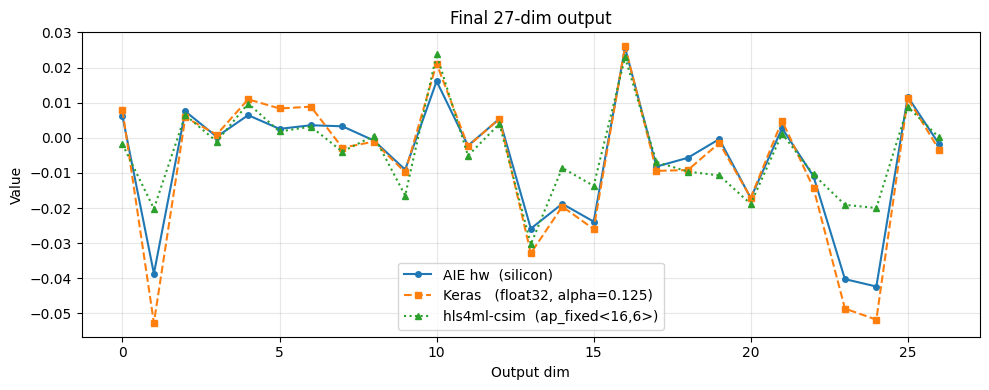

Keras  vs AIE    max|diff|=0.0140  rms=0.0047
hls4ml vs AIE    max|diff|=0.0223  rms=0.0084
hls4ml vs Keras  max|diff|=0.0325  rms=0.0116


In [9]:
import matplotlib.pyplot as plt

# Project all three chains to 27-dim final output
aie_27   = aie_s2[WARMUP:].mean(axis=0)      @ out_W + out_B
keras_27 = keras_s2out[WARMUP:].mean(axis=0) @ out_W + out_B
hls_27   = hls_s2out[WARMUP:].mean(axis=0)   @ out_W + out_B

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(aie_27,   'o-',  label='AIE hw  (silicon)',              ms=4)
ax.plot(keras_27, 's--', label='Keras   (float32, alpha=0.125)', ms=4)
ax.plot(hls_27,   '^:',  label='hls4ml-csim  (ap_fixed<16,6>)',  ms=4)
ax.set_xlabel('Output dim'); ax.set_ylabel('Value')
ax.set_title('Final 27-dim output'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'compare_27dim.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Keras  vs AIE    max|diff|={np.abs(keras_27-aie_27).max():.4f}  '
      f'rms={np.sqrt(np.mean((keras_27-aie_27)**2)):.4f}')
print(f'hls4ml vs AIE    max|diff|={np.abs(hls_27 -aie_27).max():.4f}  '
      f'rms={np.sqrt(np.mean((hls_27 -aie_27)**2)):.4f}')
print(f'hls4ml vs Keras  max|diff|={np.abs(hls_27-keras_27).max():.4f}  '
      f'rms={np.sqrt(np.mean((hls_27-keras_27)**2)):.4f}')


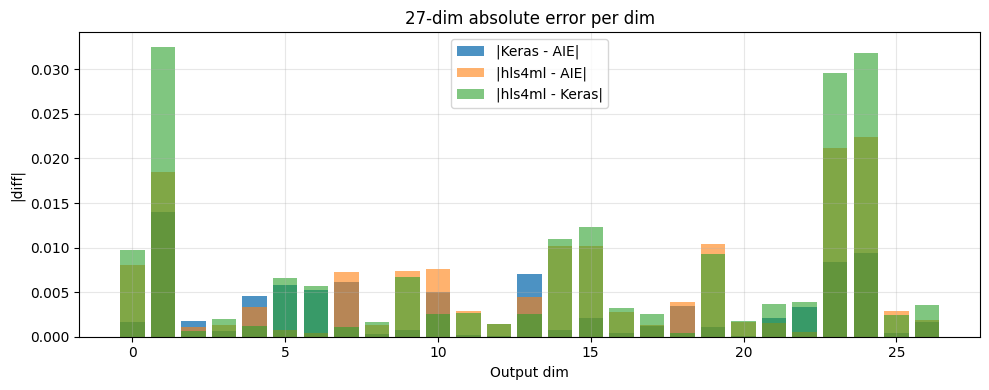

In [10]:
# Absolute error per output dim vs references
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(OUTPUT_SIZE), np.abs(keras_27 - aie_27),
       alpha=0.8, label='|Keras - AIE|')
ax.bar(range(OUTPUT_SIZE), np.abs(hls_27 - aie_27),
       alpha=0.6, label='|hls4ml - AIE|')
ax.bar(range(OUTPUT_SIZE), np.abs(hls_27 - keras_27),
       alpha=0.6, label='|hls4ml - Keras|')
ax.set_xlabel('Output dim'); ax.set_ylabel('|diff|')
ax.set_title('27-dim absolute error per dim'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'compare_27dim_err.png', dpi=100, bbox_inches='tight')
plt.show()


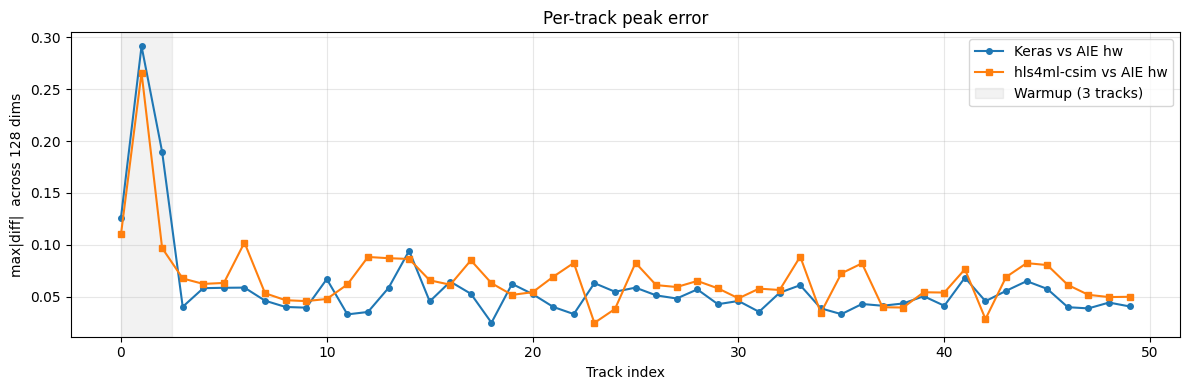

In [11]:
# Per-track max error across 128 dims — shows how error evolves track by track
diff_keras = [np.abs(keras_s2out[j] - aie_s2[j]).max() for j in range(N_TRACKS)]
diff_hls   = [np.abs(hls_s2out[j]   - aie_s2[j]).max() for j in range(N_TRACKS)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(diff_keras, 'o-', ms=4, label='Keras vs AIE hw')
ax.plot(diff_hls,   's-', ms=4, label='hls4ml-csim vs AIE hw')
ax.axvspan(0, WARMUP - 0.5, alpha=0.1, color='gray', label=f'Warmup ({WARMUP} tracks)')
ax.set_xlabel('Track index'); ax.set_ylabel('max|diff|  across 128 dims')
ax.set_title('Per-track peak error'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'compare_pertrack.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. C-Synthesis

Runs `vitis-run --tcl build_prj.tcl --mode hls` for each of the 4 models.
Expect **10–30 min per model**. Run when ready.


In [12]:
# Runs hls4ml build() for each model — same as the hls4ml tutorial.
# Expect 10-30 min per model. Edit SYNTH_MODELS to run a subset.

SYNTH_MODELS = ['embed', 'solver0', 'solver1', 'solver2']
# SYNTH_MODELS = ['solver0']

for name in SYNTH_MODELS:
    print(f'\n===== Synthesising {name} =====')
    hls_models[name].build(csim=False, synth=True, cosim=False, vsynth=False)
    print(f'{name} done.')



===== Synthesising embed =====

****** vitis-run v2024.2 (64-bit)
  **** SW Build 5239630 on 2024-11-10-11:19:46
  **** Start of session at: Wed Apr 22 22:19:27 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2024.2 5238294
Sourcing Tcl script '/home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_embed/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
INFO: [HLS 200-10] Opening project '/home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_embed/myproject_prj'.
INFO: [HLS 200-1510] Running: set_top myproject 
INFO: [HLS 200-1510] Running: add_files firmware/myproject.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb myproject_test.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding test bench file 'myproject_test.cpp' to th

INFO: [HLS 200-1995] There were 13,544 instructions in the design after the 'Unroll/Inline (step 2)' phase of compilation. See the Design Size Report for more details: /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_embed/myproject_prj/solution1/syn/report/csynth_design_size.rpt
INFO: [HLS 200-1995] There were 11,780 instructions in the design after the 'Unroll/Inline (step 3)' phase of compilation. See the Design Size Report for more details: /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_embed/myproject_prj/solution1/syn/report/csynth_design_size.rpt
INFO: [HLS 200-1995] There were 7,940 instructions in the design after the 'Unroll/Inline (step 4)' phase of compilation. See the Design Size Report for more details: /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_embed/myproject_prj/solution1/syn/report/csynth_design_size.rpt
INFO: [HLS 200-1995] There were 51,710 instructions in the design after the 'Array/Struct' p

INFO: [HLS 200-111] Finished Standard Transforms: CPU user time: 2.76 seconds. CPU system time: 0.06 seconds. Elapsed time: 2.82 seconds; current allocated memory: 790.430 MB.
INFO: [HLS 200-10] Checking synthesizability ...
INFO: [HLS 200-111] Finished Checking Synthesizability: CPU user time: 351.97 seconds. CPU system time: 0.11 seconds. Elapsed time: 352.11 seconds; current allocated memory: 897.688 MB.
INFO: [XFORM 203-602] Inlining function 'nnet::cast<ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, config2>' into 'nnet::dense_resource_rf_gt_nin_rem0<ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, config2>' (firmware/nnet_utils/nnet_dense_resource.h:164) automatically.
INFO: [XFORM 203-602] Inlining function 'nnet::cast<ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, config5>' into 'nnet::dense_resource_rf_gt_nin_rem0<ap_fixed<16, 6, (ap_

INFO: [SCHED 204-61] Pipelining loop 'ReuseLoop'.
INFO: [HLS 200-1470] Pipelining result : Target II = 1, Final II = 1, Depth = 3, loop 'ReuseLoop'
INFO: [SCHED 204-11] Finished scheduling.
INFO: [HLS 200-111] Finished Scheduling: CPU user time: 1.7 seconds. CPU system time: 0 seconds. Elapsed time: 1.71 seconds; current allocated memory: 1.537 GB.
INFO: [BIND 205-100] Starting micro-architecture generation ...
INFO: [BIND 205-101] Performing variable lifetime analysis.
INFO: [BIND 205-101] Exploring resource sharing.
INFO: [BIND 205-101] Binding ...
INFO: [BIND 205-100] Finished micro-architecture generation.
INFO: [HLS 200-111] Finished Binding: CPU user time: 0.26 seconds. CPU system time: 0.01 seconds. Elapsed time: 0.27 seconds; current allocated memory: 1.537 GB.
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-42] -- Implementing module 'dense_array_ap_fixed_128u_array_ap_fixed_16_6_5_3_0_128u_config5_s' 
INFO: [HLS 200-10] -----

INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module 'dense_array_ap_fixed_128u_array_ap_fixed_16_6_5_3_0_128u_config5_s' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [RTGEN 206-100] Finished creating RTL model for 'dense_array_ap_fixed_128u_array_ap_fixed_16_6_5_3_0_128u_config5_s'.
INFO: [HLS 200-111] Finished Creating RTL model: CPU user time: 0.88 seconds. CPU system time: 0.09 seconds. Elapsed time: 0.98 seconds; current allocated memory: 1.537 GB.
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module 'leaky_relu_array_ap_fixed_array_ap_fixed_128u_LeakyReLU_config7_s' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [RTGEN 206-100] Finished creating RTL model for 'leaky_relu_array_ap_fixed_array_ap_fixed_128u_LeakyReLU_config7_s'.
INFO: [HL

...

INFO: [HLS 200-111] Finished Architecture Synthesis: CPU user time: 1.89 seconds. CPU system time: 0.01 seconds. Elapsed time: 1.9 seconds; current allocated memory: 1.505 GB.
INFO: [HLS 200-10] Starting hardware synthesis ...
INFO: [HLS 200-10] Synthesizing 'myproject' ...
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-42] -- Implementing module 'dense_resource_rf_gt_nin_rem0_ap_fixed_ap_fixed_16_6_5_3_0_config3_s' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [SCHED 204-11] Starting scheduling ...
INFO: [SCHED 204-61] Pipelining loop 'ReuseLoop'.
INFO: [HLS 200-1470] Pipelining result : Target II = 1, Final II = 1, Depth = 3, loop 'ReuseLoop'
INFO: [SCHED 204-11] Finished scheduling.
INFO: [HLS 200-111] Finished Scheduling: CPU user time: 2.35 seconds. CPU system time: 0.11 seconds. Elapsed time: 2.45 seconds; current allocated memory: 1.505 GB.
INFO: [BIND 205-100] Starting micro-archite

INFO: [SCHED 204-11] Finished scheduling.
INFO: [HLS 200-111] Finished Scheduling: CPU user time: 0.19 seconds. CPU system time: 0.01 seconds. Elapsed time: 0.2 seconds; current allocated memory: 1.505 GB.
INFO: [BIND 205-100] Starting micro-architecture generation ...
INFO: [BIND 205-101] Performing variable lifetime analysis.
INFO: [BIND 205-101] Exploring resource sharing.
INFO: [BIND 205-101] Binding ...
INFO: [BIND 205-100] Finished micro-architecture generation.
INFO: [HLS 200-111] Finished Binding: CPU user time: 0.08 seconds. CPU system time: 0 seconds. Elapsed time: 0.08 seconds; current allocated memory: 1.505 GB.
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-42] -- Implementing module 'dense_resource_rf_gt_nin_rem0_ap_fixed_ap_fixed_16_6_5_3_0_config9_s' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [SCHED 204-11] Starting scheduling ...
INFO: [SCHED 204-61] Pipelining loop 'Reu

INFO: [SCHED 204-11] Finished scheduling.
INFO: [HLS 200-111] Finished Scheduling: CPU user time: 0.21 seconds. CPU system time: 0 seconds. Elapsed time: 0.22 seconds; current allocated memory: 1.505 GB.
INFO: [BIND 205-100] Starting micro-architecture generation ...
INFO: [BIND 205-101] Performing variable lifetime analysis.
INFO: [BIND 205-101] Exploring resource sharing.
INFO: [BIND 205-101] Binding ...
INFO: [BIND 205-100] Finished micro-architecture generation.
INFO: [HLS 200-111] Finished Binding: CPU user time: 0.17 seconds. CPU system time: 0.01 seconds. Elapsed time: 0.18 seconds; current allocated memory: 1.505 GB.
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-42] -- Implementing module 'myproject' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [SCHED 204-11] Starting scheduling ...
INFO: [SCHED 204-11] Finished scheduling.
INFO: [HLS 200-111] Finished Scheduling: CPU user time: 0

INFO: [RTGEN 206-100] Finished creating RTL model for 'add_array_array_array_ap_fixed_16_6_5_3_0_128u_config7_s'.
INFO: [HLS 200-111] Finished Creating RTL model: CPU user time: 0.18 seconds. CPU system time: 0.02 seconds. Elapsed time: 0.2 seconds; current allocated memory: 1.613 GB.
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module 'leaky_relu_array_ap_fixed_array_ap_fixed_128u_LeakyReLU_config8_s' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [RTGEN 206-100] Finished creating RTL model for 'leaky_relu_array_ap_fixed_array_ap_fixed_128u_LeakyReLU_config8_s'.
INFO: [HLS 200-111] Finished Creating RTL model: CPU user time: 0.21 seconds. CPU system time: 0.03 seconds. Elapsed time: 0.24 seconds; current allocated memory: 1.624 GB.
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module '

INFO: [RTGEN 206-100] Finished creating RTL model for 'leaky_relu_array_ap_fixed_array_ap_fixed_128u_LeakyReLU_config17_s'.
INFO: [HLS 200-111] Finished Creating RTL model: CPU user time: 0.24 seconds. CPU system time: 0.04 seconds. Elapsed time: 0.28 seconds; current allocated memory: 2.039 GB.
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module 'myproject' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [RTGEN 206-500] Setting interface mode on port 'myproject/s2_curr' to 'axis' (register, both mode).
INFO: [RTGEN 206-500] Setting interface mode on port 'myproject/s2_prev' to 'axis' (register, both mode).
INFO: [RTGEN 206-500] Setting interface mode on port 'myproject/layer17_out' to 'axis' (register, both mode).
INFO: [RTGEN 206-500] Setting interface mode on function 'myproject' to 'ap_ctrl_hs'.
INFO: [RTGEN 206-100] Finished creating RTL model for 'myproject'.

## 6. Synthesis Reports


In [13]:
def print_report(name):
    rpt = Path(HLS_DIRS[name]) / 'myproject_prj' / 'solution1' / 'syn' / 'report' / 'myproject_csynth.rpt'
    if not rpt.is_file():
        print(f'{name:8s}  synthesis not done yet')
        return
    txt = rpt.read_text().splitlines()

    # pull the Timing line (first data row under "* Summary:" under "+ Timing:")
    timing = ''
    for i, line in enumerate(txt):
        if '+ Timing:' in line:
            for l in txt[i:i+8]:
                if l.startswith('    |ap_clk'):
                    timing = l.strip()
                    break
            break

    # pull the Utilization summary: Total + Available + Utilization(%) rows
    util = []
    for i, line in enumerate(txt):
        if '== Utilization Estimates' in line:
            for l in txt[i:i+40]:
                if l.startswith('|Total') or l.startswith('|Available') or l.startswith('|Utilization'):
                    util.append(l.rstrip())
                if l.startswith('|Utilization'):
                    break
            break

    print(f'===== {name} =====')
    print(f'  {rpt}')
    if timing: print(f'  Timing: {timing}')
    for u in util:
        print(f'  {u}')
    print()

for name in ['embed', 'solver0', 'solver1', 'solver2']:
    print_report(name)


===== embed =====
  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_embed/myproject_prj/solution1/syn/report/myproject_csynth.rpt
  Timing: |ap_clk  |  5.00 ns|  3.595 ns|     1.35 ns|
  |Total            |       33|    68|    22149|   49905|    0|
  |Available        |     1200|  1312|  1041408|  520704|  264|
  |Utilization (%)  |        2|     5|        2|       9|    0|

===== solver0 =====
  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_solver0/myproject_prj/solution1/syn/report/myproject_csynth.rpt
  Timing: |ap_clk  |  5.00 ns|  3.548 ns|     1.35 ns|
  |Total            |      150|   320|    64428|  150308|    0|
  |Available        |     1200|  1312|  1041408|  520704|  264|
  |Utilization (%)  |       12|    24|        6|      28|    0|

===== solver1 =====
  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_solver1/myproject_prj/solution1/syn/report/myproject_csynth.rpt
  Timing: |ap_clk  |  5.00 ns|  3.548

## 7. ONNX Export (optional)

Exports each model as a standalone ONNX file for interop / deployment.


In [ ]:
# Uncomment if tf2onnx is not yet installed:
# import subprocess; subprocess.run(['pip', 'install', 'tf2onnx', 'onnxruntime'], check=True)

import tf2onnx
import onnx

onnx_models = [
    ('embed',   embed_model),
    ('solver0', solver0_model),
    ('solver1', solver1_model),
    ('solver2', solver2_model),
]

for name, km in onnx_models:
    out_path = str(OUT_DIR / f'{name}.onnx')
    input_sig = [tf.TensorSpec(inp.shape, tf.float32, name=inp.name.split(':')[0])
                 for inp in km.inputs]
    model_proto, _ = tf2onnx.convert.from_keras(km, input_signature=input_sig, opset=13)
    onnx.save(model_proto, out_path)
    print(f'{name:8s}  →  {out_path}')
